<a href="https://colab.research.google.com/github/imnaveenks/imnaveenks/blob/main/BBL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')


In [ ]:
matches.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,524915,Sydney,2011-12-16,BJ Haddin,Sydney Cricket Ground,0,Sydney Sixers,Brisbane Heat,Brisbane Heat,bat,Sydney Sixers,wickets,7.0,N,NaN,BNJ Oxenford,PR Reiffel
1,524916,Melbourne,2011-12-17,DA Warner,Melbourne Cricket Ground,0,Melbourne Stars,Sydney Thunder,Sydney Thunder,field,Sydney Thunder,wickets,6.0,N,NaN,SD Fry,P Wilson
2,524917,Adelaide,2011-12-18,M Klinger,Adelaide Oval,0,Adelaide Strikers,Melbourne Renegades,Melbourne Renegades,field,Adelaide Strikers,runs,67.0,N,NaN,AJ Barrow,BNJ Oxenford
3,524918,Perth,2011-12-18,BW Hilfenhaus,Western Australia Cricket Association Ground,0,Perth Scorchers,Hobart Hurricanes,Hobart Hurricanes,bat,Hobart Hurricanes,runs,31.0,N,NaN,GA Abood,AP Ward
4,524919,Brisbane,2011-12-20,RJ Quiney,"Brisbane Cricket Ground, Woolloongabba",0,Brisbane Heat,Melbourne Stars,Melbourne Stars,bat,Melbourne Stars,runs,8.0,N,NaN,IH Lock,PR Reiffel


In [ ]:
matches.shape

(414, 17)

In [ ]:
matches['winner'].value_counts()

,count
winner,
Sydney Sixers,64
Perth Scorchers,64
Melbourne Stars,55
Adelaide Strikers,51
Hobart Hurricanes,48
Melbourne Renegades,44
Brisbane Heat,44
Sydney Thunder,38


<Axes: xlabel='winner'>

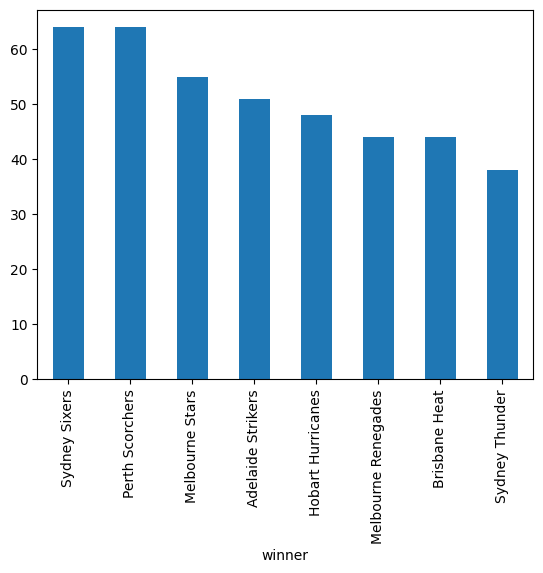

In [ ]:
win_counts = matches['winner'].value_counts()

win_counts.plot(kind='bar')

<Axes: xlabel='winner'>

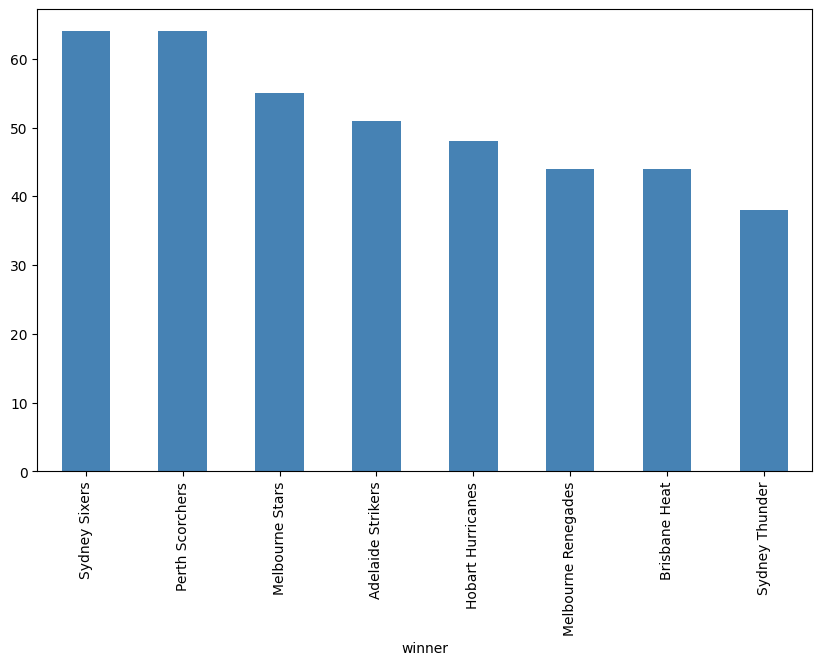

In [ ]:
win_counts.plot(kind='bar', color='steelblue', figsize=(10,6))

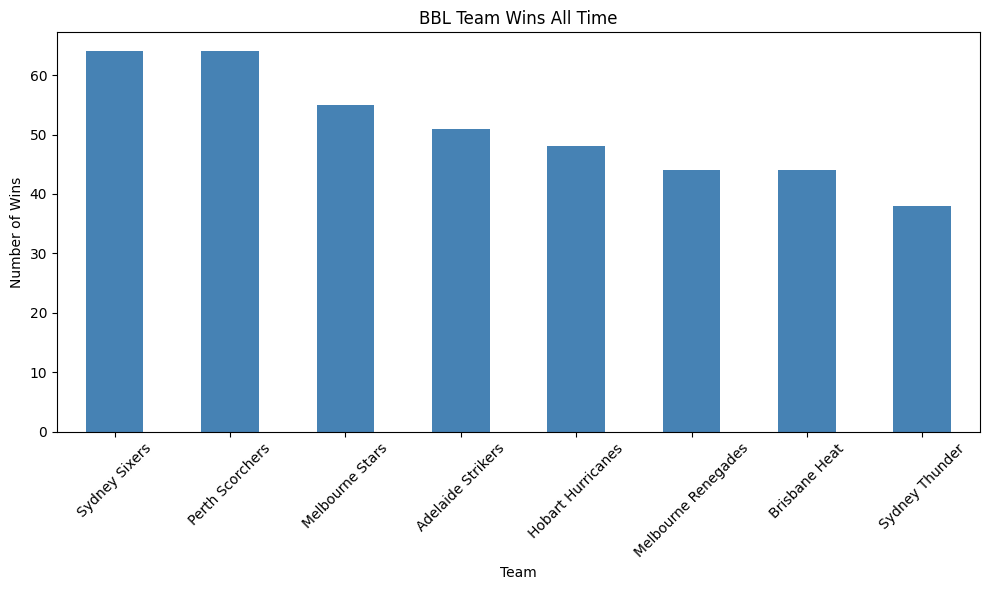

In [ ]:
import matplotlib.pyplot as plt

win_counts.plot(kind='bar', color='steelblue', figsize=(10,6))
plt.title('BBL Team Wins All Time')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
toss_win = matches[matches['toss_winner'] == matches['winner']]
toss_loss = matches[matches['toss_winner'] != matches['winner']]

print('Toss winner also won the match:', len(toss_win))
print('Toss winner lost the match:', len(toss_loss))

Toss winner also won the match: 215
Toss winner lost the match: 199


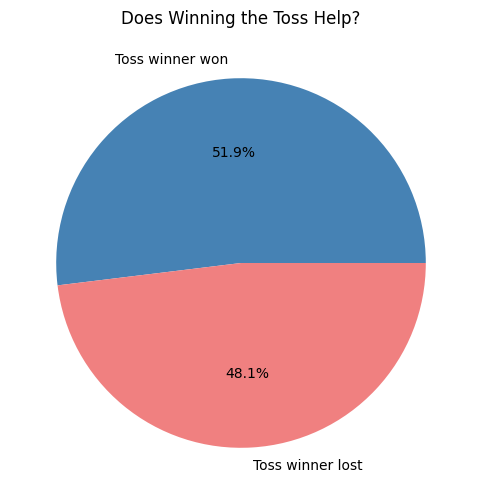

In [ ]:
plt.figure(figsize=(6,6))
plt.pie([215, 199], labels=['Toss winner won', 'Toss winner lost'],
        autopct='%1.1f%%', colors=['steelblue', 'lightcoral'])
plt.title('Does Winning the Toss Help?')
plt.show()

In [ ]:
perth = matches[matches['team1'] == 'Perth Scorchers']
home_wins = perth[perth['venue'].str.contains('Perth') & (perth['winner'] == 'Perth Scorchers')]
away_wins = perth[~perth['venue'].str.contains('Perth') & (perth['winner'] == 'Perth Scorchers')]

print('Perth Scorchers home wins:', len(home_wins))
print('Perth Scorchers away wins:', len(away_wins))

Perth Scorchers home wins: 9
Perth Scorchers away wins: 30


In [ ]:
print(matches['venue'].unique())

['Sydney Cricket Ground' 'Melbourne Cricket Ground' 'Adelaide Oval'
 'Western Australia Cricket Association Ground'
 'Brisbane Cricket Ground, Woolloongabba' 'Bellerive Oval'
 'Docklands Stadium' 'Stadium Australia' 'Sydney Showground Stadium'
 'Manuka Oval' 'W.A.C.A. Ground' 'Aurora Stadium'
 'Simonds Stadium, South Geelong, Victoria' 'Traeger Park' 'Perth Stadium'
 'Carrara Oval' 'Geelong Cricket Ground' 'Ted Summerton Reserve'
 'International Sports Stadium' 'Brisbane Cricket Ground']


In [ ]:
perth = matches[matches['team1'] == 'Perth Scorchers']
home_wins = perth[perth['venue'].str.contains('WACA|Perth Stadium') & (perth['winner'] == 'Perth Scorchers')]
away_wins = perth[~perth['venue'].str.contains('WACA|Perth Stadium') & (perth['winner'] == 'Perth Scorchers')]

print('Perth Scorchers home wins:', len(home_wins))
print('Perth Scorchers away wins:', len(away_wins))

Perth Scorchers home wins: 9
Perth Scorchers away wins: 30


In [ ]:
perth = matches[(matches['team1'] == 'Perth Scorchers') | (matches['team2'] == 'Perth Scorchers')]

print(perth['venue'].value_counts())

venue
Western Australia Cricket Association Ground    30
Perth Stadium                                   19
Sydney Cricket Ground                           10
Adelaide Oval                                    8
Melbourne Cricket Ground                         7
Docklands Stadium                                7
Brisbane Cricket Ground, Woolloongabba           5
Bellerive Oval                                   5
Manuka Oval                                      5
W.A.C.A. Ground                                  5
Sydney Showground Stadium                        4
Aurora Stadium                                   2
Traeger Park                                     1
Carrara Oval                                     1
Simonds Stadium, South Geelong, Victoria         1
Name: count, dtype: int64


In [ ]:
home_venues = ['Western Australia Cricket Association Ground', 'Perth Stadium', 'W.A.C.A. Ground']

home_wins = perth[perth['venue'].isin(home_venues) & (perth['winner'] == 'Perth Scorchers')]
away_wins = perth[~perth['venue'].isin(home_venues) & (perth['winner'] == 'Perth Scorchers')]

print('Perth Scorchers home wins:', len(home_wins))
print('Perth Scorchers away wins:', len(away_wins))

Perth Scorchers home wins: 35
Perth Scorchers away wins: 29


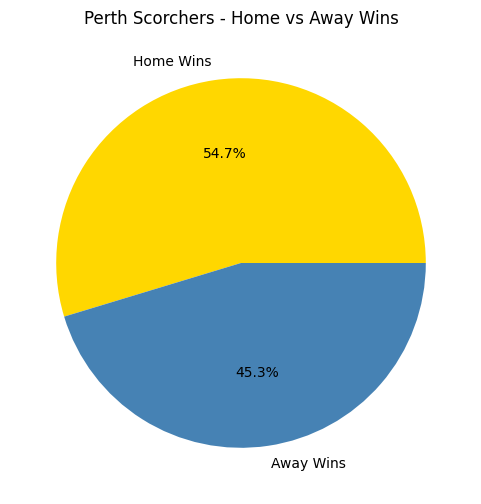

In [ ]:
plt.figure(figsize=(6,6))
plt.pie([35, 29], labels=['Home Wins', 'Away Wins'],
        autopct='%1.1f%%', colors=['gold', 'steelblue'])
plt.title('Perth Scorchers - Home vs Away Wins')
plt.show()

In [ ]:
top_scorers = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print(top_scorers)


batsman
CA Lynn         2745
AJ Finch        2430
SE Marsh        2188
DJM Short       2109
MP Stoinis      2105
GJ Maxwell      2084
JW Wells        1989
MC Henriques    1898
CJ Ferguson     1882
MS Wade         1799
Name: batsman_runs, dtype: int64


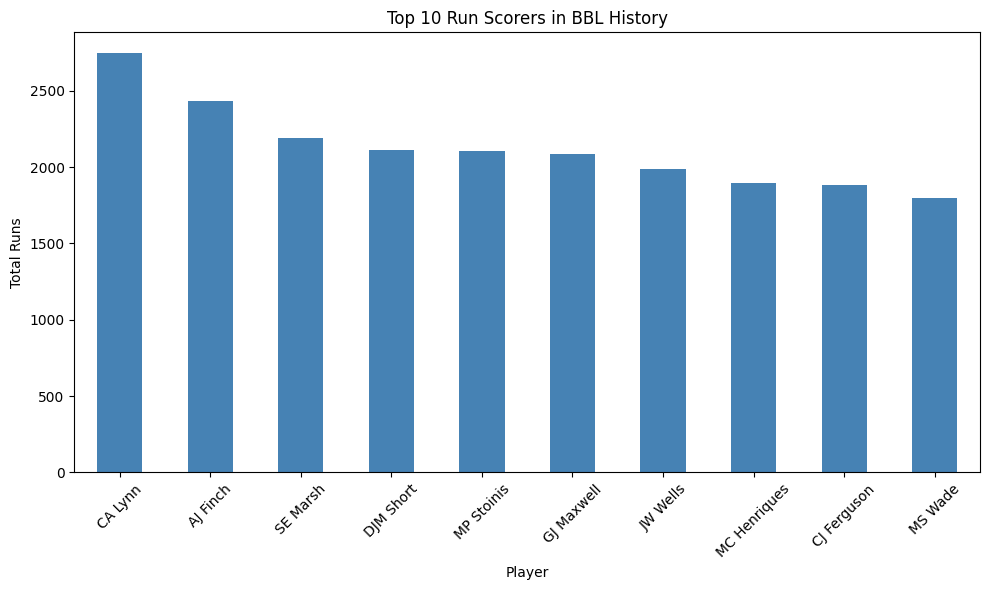

In [ ]:
plt.figure(figsize=(10,6))
top_scorers.plot(kind='bar', color='steelblue')
plt.title('Top 10 Run Scorers in BBL History')
plt.xlabel('Player')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()